In [136]:
import polars as pl
import polars.selectors as cs
from pathlib import Path
import json

import seaborn as sns

sns.set_theme()

Counting how many mixed dementia cases we have, from all datasets. Let's start from NACC.

In [31]:
nacc_datadict_path = Path("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/NACC_dictionary.json")
nacc_train_path = Path('/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/train.csv')
nacc_test_path = Path('/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/test.csv')

In [32]:
with nacc_datadict_path.open() as f:
    nacc_datadict = json.load(f)

In [144]:
nacc_train = pl.scan_csv(nacc_test_path)

In [145]:
D1 = [dict(
    form=nacc_datadict[k]['FORM ID'],
    description=nacc_datadict[k]['Description'],
    Variable=k
    ) for k in nacc_datadict if nacc_datadict[k]['FORM ID'] == "D1"]

diagnoses = pl.DataFrame(D1).filter(
            (pl.col("description").str.contains("Presumptive etiologi"))
        ).sort('Variable')

diagnoses_columns = set(nacc_train.collect_schema().names()).intersection(set(diagnoses['Variable'].to_list()))

In [146]:
nacc_count_diag = (
    nacc_train.select("NACCID", pl.col(sorted(diagnoses_columns)))
    .cast({cs.numeric(): pl.Int64})
    .with_columns(cs.numeric().replace([-4, 8], None))
    .with_columns(pl.all().replace({0:None}))
    .drop(["OTHCOGX", "OTHPSYX"])
    .unpivot(index='NACCID')
    .drop_nulls()
    .drop('value')
    .group_by('NACCID').all()
    .with_columns(pl.col('variable').list.len().alias("num_diagnoses"))
    .sort("num_diagnoses")
    .collect()
)

In [147]:
nacc_count_diag.select(
    pl.col('num_diagnoses').value_counts()
).unnest('num_diagnoses').sort('num_diagnoses')

num_diagnoses,count
u32,u32
1,2823
2,1440
3,422
4,132
5,33
6,7
7,1


<Axes: xlabel='num_diagnoses', ylabel='count'>

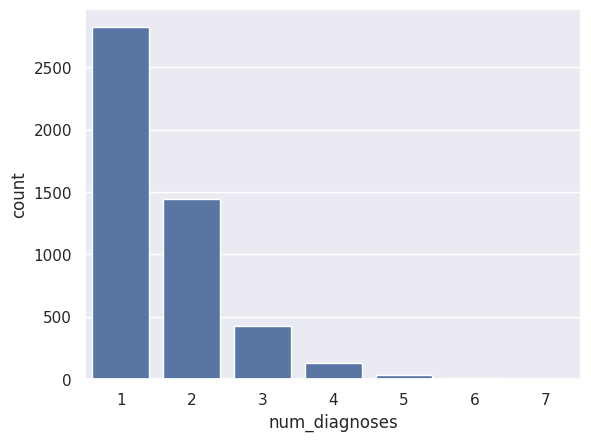

In [148]:
sns.countplot(
    nacc_count_diag.to_pandas(),
    x='num_diagnoses',
)